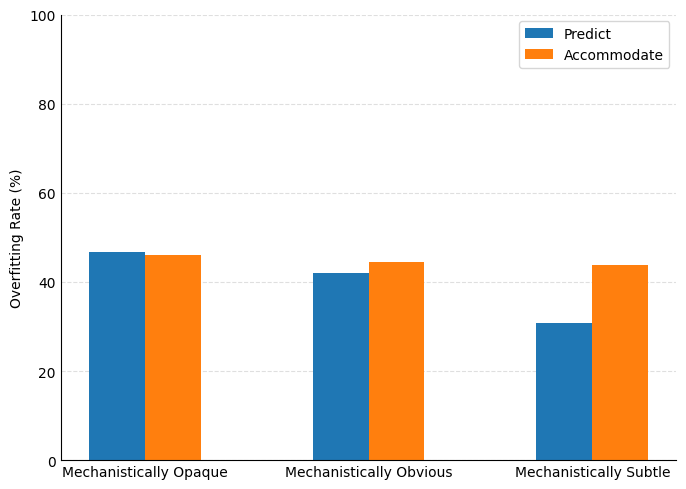

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# Base directory
base_path = "/Users/sm6511/Desktop/Prediction-Accomodation-Exp/data/Combined"
output_path = "/Users/sm6511/Desktop/Prediction-Accomodation-Exp/Analysis/Plots/Combined"

# File names
files = [
    "overfit_summary_study1.csv",
    "overfit_summary_study2.csv",
    "overfit_summary_study3.csv"
]

# Load + combine
dfs = [pd.read_csv(os.path.join(base_path, f)) for f in files]
df_all = pd.concat(dfs, ignore_index=True)

# Ordering
df_all['study'] = pd.Categorical(
    df_all['study'],
    categories=['Study 1', 'Study 2', 'Study 3'],
    ordered=True
)

df_all['task'] = pd.Categorical(
    df_all['task'],
    categories=['predict', 'accommodate'],
    ordered=True
)

# Sort for plotting
df_all = df_all.sort_values(['study', 'task'])

# Plot
fig, ax = plt.subplots(figsize=(7, 5))

x = np.arange(len(df_all['study'].unique()))
width = 0.25

# Split by task
predict_vals = df_all[df_all['task'] == 'predict']['overfit_percent'].values
accom_vals   = df_all[df_all['task'] == 'accommodate']['overfit_percent'].values

# Colors
colors = {
    'predict': '#1f77b4',
    'accommodate': '#ff7f0e'
}

# Bars
ax.bar(x - width/2, predict_vals, width, label='Predict', color=colors['predict'])
ax.bar(x + width/2, accom_vals, width, label='Accommodate', color=colors['accommodate'])

# Labels
ax.set_xticks(x)
custom_labels = ['Mechanistically Opaque', 'Mechanistically Obvious', 'Mechanistically Subtle']  # Custom labels
ax.set_xticklabels(custom_labels)

ax.set_ylabel('Overfitting Rate (%)')
#ax.set_title('Overfitting Across Experiments')
ax.set_ylim(0, 100)

# Clean style
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
ax.tick_params(axis='both', length=0)

ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(output_path, "overfitting_combined.png"), dpi=300)
plt.show()

In [5]:
# File names
files = [
    "df_long_for_R-Study1.csv",
    "df_long_for_R-Study2.csv",
    "df_long_for_R-Study3.csv"
]

dfs = []
for i, f in enumerate(files, start=1):
    df = pd.read_csv(os.path.join(base_path, f))
    df['study'] = f"Study {i}"
    df['abs_feature_importance'] = df['feature_importance'].abs()
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)


/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_13942/693700778.py:57: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(custom_labels, fontsize=10)
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_13942/693700778.py:57: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(custom_labels, fontsize=10)


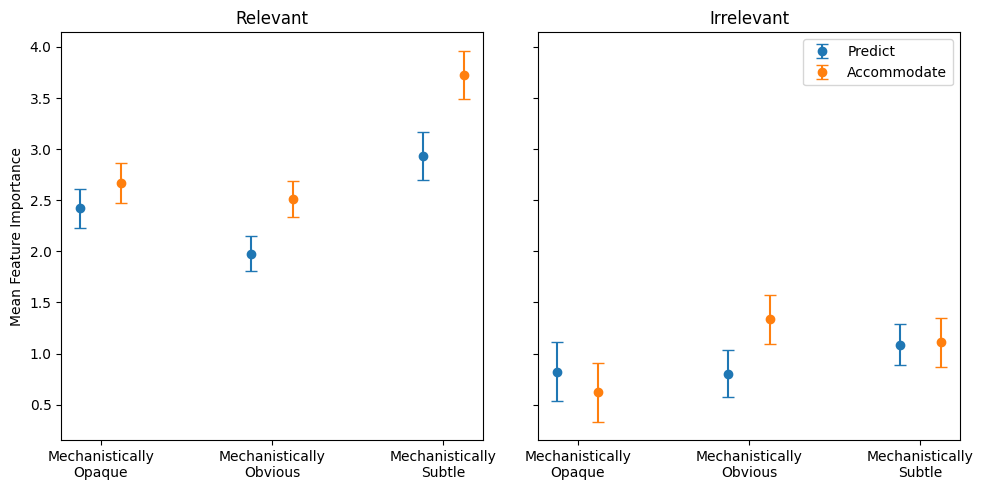

In [6]:
summary = (
    df_all
    .groupby(['study', 'task', 'feature_relevance'])['feature_importance']
    .agg(['mean', 'std', 'count'])
    .reset_index()
)

summary['se'] = summary['std'] / np.sqrt(summary['count'])

study_order = ['Study 1', 'Study 2', 'Study 3']
task_order = ['predict', 'accommodate']
relevance_order = ['relevant', 'irrelevant']

summary['study'] = pd.Categorical(summary['study'], categories=study_order, ordered=True)
summary['task'] = pd.Categorical(summary['task'], categories=task_order, ordered=True)
summary['feature_relevance'] = pd.Categorical(
    summary['feature_relevance'],
    categories=relevance_order,
    ordered=True
)

summary = summary.sort_values(['feature_relevance', 'study', 'task'])

x = np.arange(len(study_order))
offset = 0.12

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

for ax, rel_type in zip(axes, relevance_order):
    rel_data = summary[summary['feature_relevance'] == rel_type]
    
    pred = rel_data[rel_data['task'] == 'predict']
    accom = rel_data[rel_data['task'] == 'accommodate']
    
    ax.errorbar(
        x - offset,
        pred['mean'],
        yerr=pred['se'],
        fmt='o',
        capsize=4,
        label='Predict'
    )
    
    ax.errorbar(
        x + offset,
        accom['mean'],
        yerr=accom['se'],
        fmt='o',
        capsize=4,
        label='Accommodate'
    )
    custom_labels = [
    'Mechanistically\nOpaque',
    'Mechanistically\nObvious',
    'Mechanistically\nSubtle'
]  
    ax.set_xticklabels(custom_labels, fontsize=10)
    ax.set_xticks(x)
    ax.set_title(rel_type.capitalize())

axes[0].set_ylabel("Mean Feature Importance")
axes[1].legend()

#fig.suptitle("Feature Importance by Task Across Experiments")
plt.tight_layout()
plt.savefig(os.path.join(output_path, "feature_importance_combined.png"), dpi=300)
plt.show()

/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_13942/751578478.py:58: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(custom_labels, fontsize=10)
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_13942/751578478.py:58: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(custom_labels, fontsize=10)


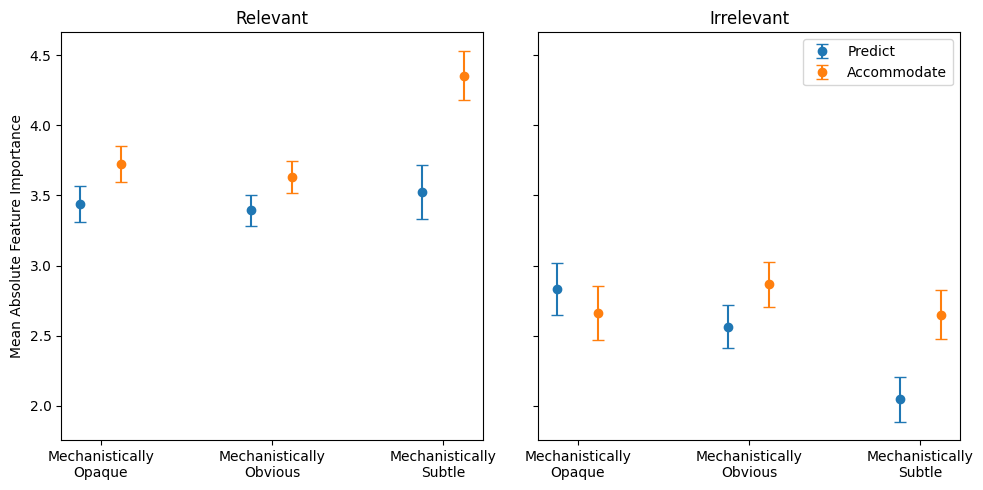

In [7]:
summary = (
    df_all
    .groupby(['study', 'task', 'feature_relevance'])['abs_feature_importance']
    .agg(['mean', 'std', 'count'])
    .reset_index()
)

summary['se'] = summary['std'] / np.sqrt(summary['count'])

study_order = ['Study 1', 'Study 2', 'Study 3']
task_order = ['predict', 'accommodate']
relevance_order = ['relevant', 'irrelevant']

summary['study'] = pd.Categorical(summary['study'], categories=study_order, ordered=True)
summary['task'] = pd.Categorical(summary['task'], categories=task_order, ordered=True)
summary['feature_relevance'] = pd.Categorical(
    summary['feature_relevance'],
    categories=relevance_order,
    ordered=True
)

summary = summary.sort_values(['feature_relevance', 'study', 'task'])

x = np.arange(len(study_order))
offset = 0.12

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

for ax, rel_type in zip(axes, relevance_order):
    rel_data = summary[summary['feature_relevance'] == rel_type]
    
    pred = rel_data[rel_data['task'] == 'predict']
    accom = rel_data[rel_data['task'] == 'accommodate']
    
    ax.errorbar(
        x - offset,
        pred['mean'],
        yerr=pred['se'],
        fmt='o',
        capsize=4,
        label='Predict'
    )
    
    ax.errorbar(
        x + offset,
        accom['mean'],
        yerr=accom['se'],
        fmt='o',
        capsize=4,
        label='Accommodate'
    )
    
    custom_labels = [
    'Mechanistically\nOpaque',
    'Mechanistically\nObvious',
    'Mechanistically\nSubtle'
]  
    ax.set_xticklabels(custom_labels, fontsize=10)
    ax.set_xticks(x)
    ax.set_title(rel_type.capitalize())

axes[0].set_ylabel("Mean Absolute Feature Importance")
axes[1].legend()

#fig.suptitle("Absolute Feature Importance by Task Across Experiments")
plt.tight_layout()
plt.savefig(os.path.join(output_path, "abs_feature_importance_combined.png"), dpi=300)
plt.show()

In [27]:
import statsmodels.formula.api as smf
df_long = dfs[1]
#T. Predict: tests task differences for irrelevant features
#interaction: tests whether the predict v accommodate effect changes across relevant vs irrelevant features
#The predict vs. accommodate gap is 1.8 units larger for relevant features than for irrelevant features.
#Predict v accommodate ratings are close for relevant features, but far apart for irrelevant
df_long['feature_relevance'] = pd.Categorical(df_long['feature_relevance'], categories=['relevant', 'irrelevant'], ordered=False)

model = smf.mixedlm(
    "feature_importance ~ task * feature_relevance",
    df_long,
    groups=df_long["participant"]
).fit()

print(model.summary())


                          Mixed Linear Model Regression Results
Model:                      MixedLM         Dependent Variable:         feature_importance
No. Observations:           1254            Method:                     REML              
No. Groups:                 418             Scale:                      11.4981           
Min. group size:            3               Log-Likelihood:             -3346.6930        
Max. group size:            3               Converged:                  Yes               
Mean group size:            3.0                                                           
------------------------------------------------------------------------------------------
                                                Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------------------
Intercept                                        2.512    0.176 14.291 0.000  2.167  2.856
task[T.predict]           

In [30]:
df_long = dfs[1].copy()

df_long['abs_importance'] = df_long['feature_importance'].abs()

import statsmodels.formula.api as smf
df_long['feature_relevance'] = pd.Categorical(df_long['feature_relevance'], categories=['irrelevant', 'relevant'], ordered=False)

model = smf.mixedlm(
    "abs_importance ~ task * feature_relevance",
    df_long,
    groups=df_long["participant"]
).fit()

print(model.summary())

                         Mixed Linear Model Regression Results
Model:                      MixedLM          Dependent Variable:          abs_importance
No. Observations:           1254             Method:                      REML          
No. Groups:                 418              Scale:                       4.5880        
Min. group size:            3                Log-Likelihood:              -2816.1993    
Max. group size:            3                Converged:                   Yes           
Mean group size:            3.0                                                         
----------------------------------------------------------------------------------------
                                              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------------------------------
Intercept                                      2.866    0.159 18.007 0.000  2.554  3.178
task[T.predict]                               -

In [28]:
import statsmodels.formula.api as smf
df_long = dfs[2]
#T. Predict: tests task differences for irrelevant features
#interaction: tests whether the predict v accommodate effect changes across relevant vs irrelevant features
#The predict vs. accommodate gap is 1.8 units larger for relevant features than for irrelevant features.
#Predict v accommodate ratings are close for relevant features, but far apart for irrelevant
df_long['feature_relevance'] = pd.Categorical(df_long['feature_relevance'], categories=['relevant', 'irrelevant'], ordered=False)

model = smf.mixedlm(
    "feature_importance ~ task * feature_relevance",
    df_long,
    groups=df_long["participant"]
).fit()

print(model.summary())


                          Mixed Linear Model Regression Results
Model:                      MixedLM         Dependent Variable:         feature_importance
No. Observations:           868             Method:                     REML              
No. Groups:                 434             Scale:                      11.1189           
Min. group size:            2               Log-Likelihood:             -2277.2583        
Max. group size:            2               Converged:                  Yes               
Mean group size:            2.0                                                           
------------------------------------------------------------------------------------------
                                                Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------------------
Intercept                                        3.728    0.226 16.470 0.000  3.284  4.172
task[T.predict]           

/opt/miniconda3/envs/PredictProj/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [61]:
import statsmodels.formula.api as smf
df_long = dfs[2]
#T. Predict: tests task differences for irrelevant features
#interaction: tests whether the predict v accommodate effect changes across relevant vs irrelevant features
#The predict vs. accommodate gap is 1.8 units larger for relevant features than for irrelevant features.
#Predict v accommodate ratings are close for relevant features, but far apart for irrelevant
df_long['feature_relevance'] = pd.Categorical(df_long['feature_relevance'], categories=['irrelevant', 'relevant'], ordered=False)

model = smf.mixedlm(
    "abs_feature_importance ~ task * feature_relevance",
    df_long,
    groups=df_long["participant"]
).fit()

print(model.summary())


                         Mixed Linear Model Regression Results
Model:                    MixedLM       Dependent Variable:       abs_feature_importance
No. Observations:         868           Method:                   REML                  
No. Groups:               434           Scale:                    6.3972                
Min. group size:          2             Log-Likelihood:           -2056.8399            
Max. group size:          2             Converged:                Yes                   
Mean group size:          2.0                                                           
----------------------------------------------------------------------------------------
                                              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------------------------------
Intercept                                      2.650    0.175 15.101 0.000  2.306  2.994
task[T.predict]                               -